In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/sunwoo604/CSCI566_project.git
%cd CSCI566_project/preprocessing
!ls

Cloning into 'CSCI566_project'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 55 (delta 18), reused 44 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 1.00 MiB | 4.10 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/CSCI566_project/preprocessing
image_processing.py  unpack.py


In [86]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.metrics import cohen_kappa_score

from unpack import unpack_data, unpack_label, image_to_score
from image_processing import resize_images, apply_clahe, normalize_images

In [99]:
# !cp "/content/drive/MyDrive/Colab Notebooks/CSCI566/eyepacs/normalized_full.zip" /content/
# !unzip -q /content/normalized_full.zip -d /content/
normalized_dir = "/content/normalized_full"
print(f"files: {len(os.listdir('/content/normalized_full'))}")

files: 35126


In [100]:
import torchvision.transforms as transforms

class DRDataset(Dataset):
    def __init__(self, data_dir, label_dict, files=None, augment=False):
        self.data_dir = data_dir
        self.label_dict = label_dict
        self.augment = augment
        if files is not None:
            self.files = files
        else:
            self.files = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        img = np.load(os.path.join(self.data_dir, file_name))  # (H,W,3)
        img = torch.tensor(img).permute(2,0,1).float()  # (3,H,W)

        if self.augment:
          # if np.random.rand() > 0.5:
            transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(360),
                # transforms.ColorJitter(brightness=0.1, contrast=0.1), # 밝기/대비 변화 추가
            ])
            img = transform(img)

        label = int(self.label_dict[file_name.replace(".npy","")])
        return img, label

In [101]:
from sklearn.model_selection import train_test_split

label_dict = image_to_score("/content/drive/MyDrive/Colab Notebooks/CSCI566/eyepacs/trainLabels.csv")

dataset = DRDataset(normalized_dir, label_dict)
files = dataset.files
labels_list = [label_dict[f.replace(".npy", "")] for f in files]

# stratified split (70/15/15)
train_files, temp_files, train_labels, temp_labels = train_test_split(
    files, labels_list, test_size=0.3, stratify=labels_list, random_state=42
)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

train_dataset = DRDataset(normalized_dir, label_dict, files=train_files, augment=True)
val_dataset = DRDataset(normalized_dir, label_dict, files=val_files, augment=False)
test_dataset = DRDataset(normalized_dir, label_dict, files=test_files, augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [102]:
def init_weights_kaiming(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [103]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)
model.apply(init_weights_kaiming)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.0),
    nn.Linear(num_ftrs, 5)
)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = True

In [104]:
# class weight

from collections import Counter
labels_list = [label_dict[f.replace(".npy", "")] for f in dataset.files]
class_counts = Counter(labels_list)
print("클래스별 샘플 수:", class_counts)
total = sum(class_counts.values())
#1
# class_weights = torch.tensor([
#     total / class_counts[str(i)] for i in range(5)
# ], dtype=torch.float32).to(device)

#2
# class_weights = torch.tensor([
#     np.log(total / class_counts[str(i)]) for i in range(5)
# ], dtype=torch.float32).to(device)

#3
# beta = 0.99
# effective_num = [(1.0 - beta**class_counts[str(i)]) / (1.0 - beta) for i in range(5)]
# class_weights = torch.tensor([1.0 / sn for sn in effective_num], dtype=torch.float32)
# class_weights = class_weights / class_weights.sum() * 5
# class_weights = class_weights.to(device)

#4
class_weights = torch.tensor([
    np.sqrt(total / class_counts[str(i)]) for i in range(5)
], dtype=torch.float32).to(device)

클래스별 샘플 수: Counter({'0': 25810, '2': 5292, '1': 2443, '3': 873, '4': 708})


In [105]:
# loss + optimizer

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-4
)

from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

warmup_scheduler = LinearLR(optimizer, start_factor=0.2, end_factor=1.0, total_iters=10)
main_scheduler = CosineAnnealingLR(optimizer, T_max=140)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, main_scheduler], milestones=[10])

Epoch 1, Train Loss: 1.3932, Val Loss: 1.4814, Val QWK: 0.0011, Val Acc: 64.59%, LR: 0.00008400
  → best_qwk_model 저장 (QWK: 0.0011)
  → best_loss_model 저장 (Loss: 1.4814)


Epoch 2, Train Loss: 1.3980, Val Loss: 1.3704, Val QWK: 0.0683, Val Acc: 71.65%, LR: 0.00010800
  → best_qwk_model 저장 (QWK: 0.0683)
  → best_loss_model 저장 (Loss: 1.3704)


Epoch 3, Train Loss: 1.3743, Val Loss: 1.3534, Val QWK: 0.0519, Val Acc: 72.03%, LR: 0.00013200
  → best_loss_model 저장 (Loss: 1.3534)


Epoch 4, Train Loss: 1.3685, Val Loss: 1.3304, Val QWK: 0.0000, Val Acc: 73.47%, LR: 0.00015600
  → best_loss_model 저장 (Loss: 1.3304)


Epoch 5, Train Loss: 1.3542, Val Loss: 1.3459, Val QWK: 0.0073, Val Acc: 73.33%, LR: 0.00018000


...

Epoch 146, Train Loss: 1.0342, Val Loss: 1.0301, Val QWK: 0.5848, Val Acc: 73.32%, LR: 0.00000060


Epoch 147, Train Loss: 1.0346, Val Loss: 1.0303, Val QWK: 0.5822, Val Acc: 73.22%, LR: 0.00000034


Epoch 148, Train Loss: 1.0328, Val Loss: 1.0306, Val QWK: 0.5845, Val Acc: 73.11%, LR: 0.00000015


Epoch 149, Train Loss: 1.0351, Val Loss: 1.0301, Val QWK: 0.5866, Val Acc: 73.14%, LR: 0.00000004


Epoch 150, Train Loss: 1.0320, Val Loss: 1.0305, Val QWK: 0.5877, Val Acc: 73.51%, LR: 0.00000000


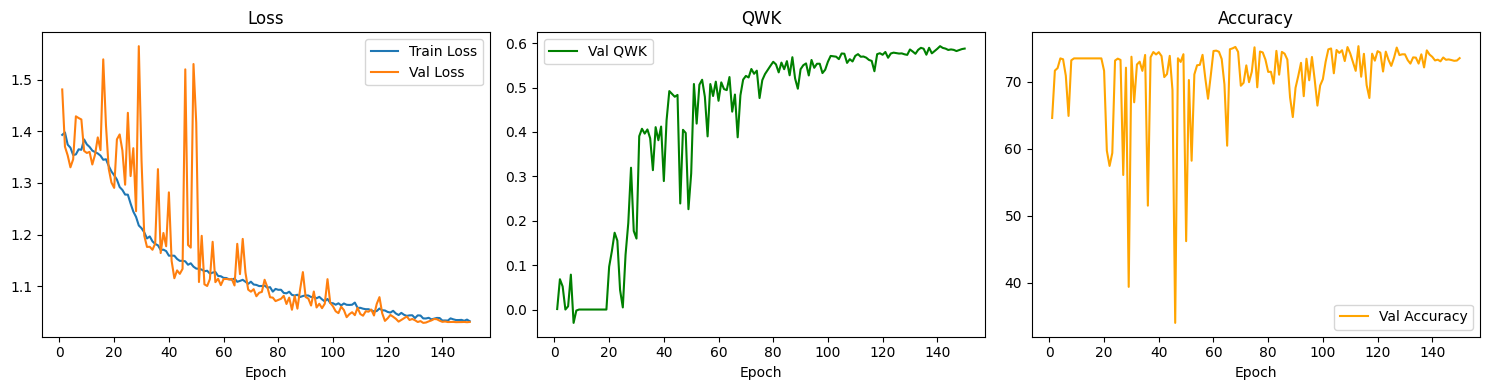

In [106]:
from tqdm import tqdm

num_epochs = 150
best_val_loss = float('inf')
best_qwk = -1.0
patience = 20
counter = 0

# 기록용 리스트
train_losses = []
val_losses = []
val_qwks = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", position=0, leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    model.eval()
    val_loss = 0.0
    all_val_preds = []
    all_val_labels = []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating", position=0, leave=False):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    val_qwk = cohen_kappa_score(all_val_labels, all_val_preds, weights='quadratic')
    accuracy = 100 * sum(p == l for p, l in zip(all_val_preds, all_val_labels)) / len(all_val_labels)

    # 기록
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_qwks.append(val_qwk)
    val_accs.append(accuracy)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val QWK: {val_qwk:.4f}, Val Acc: {accuracy:.2f}%, LR: {current_lr:.8f}")
    # 모델 저장 (QWK 기준)
    if val_qwk > best_qwk:
        best_qwk = val_qwk
        torch.save(model.state_dict(), "best_qwk_model.pth")
        print(f"  → best_qwk_model 저장 (QWK: {best_qwk:.4f})")

    # 모델 저장 + 얼리스타핑 (val loss 기준)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_loss_model.pth")
        print(f"  → best_loss_model 저장 (Loss: {best_val_loss:.4f})")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# 그래프
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, train_losses, label='Train Loss')
axes[0].plot(epochs, val_losses, label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, val_qwks, label='Val QWK', color='green')
axes[1].set_title('QWK')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs, val_accs, label='Val Accuracy', color='orange')
axes[2].set_title('Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

In [109]:
# Test
from sklearn.metrics import cohen_kappa_score, roc_auc_score
from collections import Counter
import numpy as np

for model_name in ["best_loss_model.pth", "best_qwk_model.pth"]:
    print(f"\n=== {model_name} ===")
    model.load_state_dict(torch.load(model_name))
    model.eval()

    test_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = 100 * (all_preds == all_labels).sum() / len(all_labels)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    print(f"Test Loss: {test_loss/len(test_loader):.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"QWK: {qwk:.4f}")
    print(f"AUC: {auc:.4f}")
    print("predictions:", Counter(all_preds.tolist()))
    print("actuals:", Counter(all_labels.tolist()))


=== best_loss_model.pth ===
Test Loss: 1.0395
Test Accuracy: 74.83%
QWK: 0.6006
AUC: 0.7992
predictions: Counter({0: 4300, 2: 740, 4: 147, 3: 82})
actuals: Counter({0: 3872, 2: 794, 1: 366, 3: 131, 4: 106})

=== best_qwk_model.pth ===
Test Loss: 1.0466
Test Accuracy: 73.85%
QWK: 0.5972
AUC: 0.7921
predictions: Counter({0: 4196, 2: 815, 4: 178, 3: 80})
actuals: Counter({0: 3872, 2: 794, 1: 366, 3: 131, 4: 106})



=== best_loss_model.pth ===


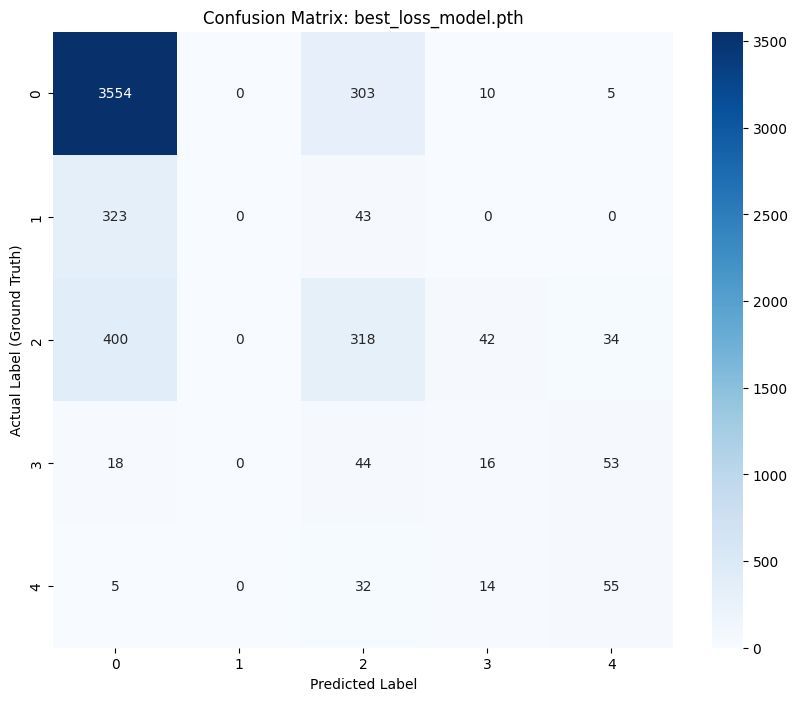


=== best_qwk_model.pth ===


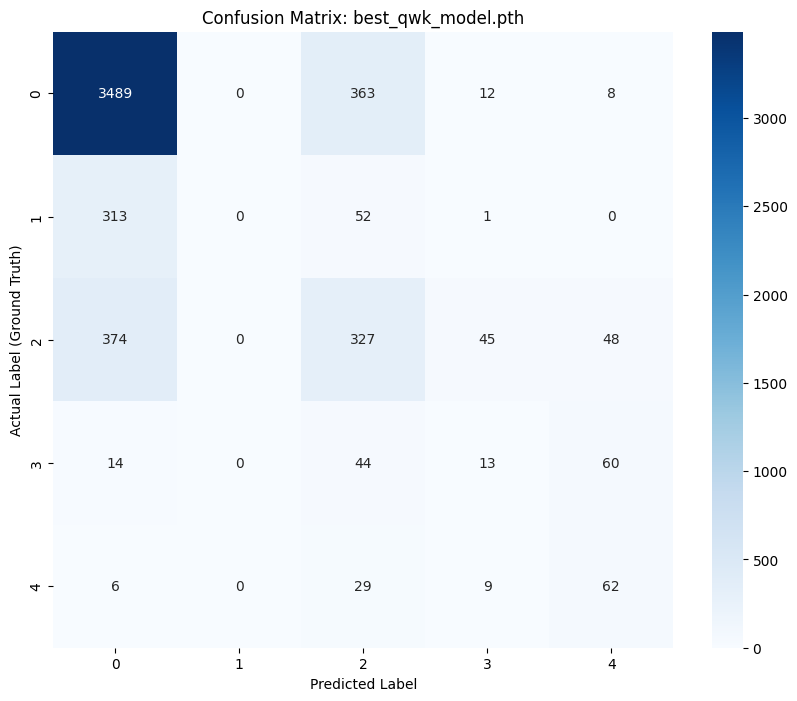

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(all_labels, all_preds, classes, title):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual Label (Ground Truth)')
    plt.xlabel('Predicted Label')
    plt.show()

class_names = ['0', '1', '2', '3', '4']

for model_name in ["best_loss_model.pth", "best_qwk_model.pth"]:
    print(f"\n=== {model_name} ===")
    model.load_state_dict(torch.load(model_name))
    model.eval()

    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    plot_confusion_matrix(all_labels, all_preds, class_names, model_name)